# Hierarchical forecasting II with `numpyro_forecast`

This notebook ports the blog post [**Hierarchical forecasting with NumPyro (part II)**](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_2/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. It extends [part I](hierarchical_forecasting_1.ipynb) to the **full 50x50 origin-destination panel**, adding a static **pairwise** station affinity and **separate origin/destination noise scales**.

We subclass `numpyro_forecast.ForecastingModel` and let `Forecaster` handle the *fit-once / forecast-any-horizon* mechanics. Visualizations use **ArviZ >= 1.0** (`az.hdi` + `fill_between`).

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism rather than re-running the guide over the full covariates. Because the full panel is large, predictive draws are done in memory-bounded batches.

## Prepare notebook

In [1]:
from typing import cast

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import xarray as xr
from jax import random
from jax.tree_util import tree_map
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast.datasets import load_bart_hierarchical
from numpyro_forecast.evaluate import eval_crps
from numpyro_forecast.forecaster import Forecaster, ForecastingModel
from numpyro_forecast.typing import Array
from numpyro_forecast.util import periodic_repeat

numpyro.set_host_device_count(n=4)
plt.rcParams["figure.figsize"] = (10, 4)

rng_key = random.PRNGKey(seed=42)
period = 24 * 7  # weekly seasonality (hours)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

We load the full windowed origin-destination panel (`log1p` counts, 90 training days + 2 test weeks) in the package convention `(origin, time, destin)` (time at axis `-2`).

data shape: (50, 2496, 50) | split: 2160


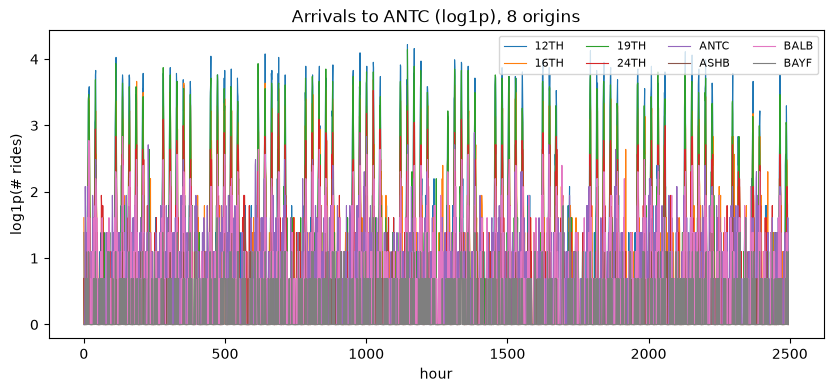

In [2]:
y, split, stations = load_bart_hierarchical()
n_origin, _, n_destin = y.shape
print("data shape:", y.shape, "| split:", split)

antc = stations.index("ANTC")
fig, ax = plt.subplots()
for i in range(8):
    ax.plot(np.asarray(y[i, :, antc]), lw=0.8, label=stations[i])
ax.legend(ncol=4, fontsize=8)
ax.set(title="Arrivals to ANTC (log1p), 8 origins", xlabel="hour", ylabel="log1p(# rides)");

## Train-test split

The last two weeks (`336` hours) are held out. Covariates are dummy zeros over the panel; only their shape is used.

In [3]:
T0 = 0
T1 = split  # 2160
T2 = y.shape[1]  # 2496

y_train = y[:, T0:T1, :]
y_test = y[:, T1:T2, :]
covariates = jnp.zeros((n_origin, T2, n_destin))
covariates_train = covariates[:, T0:T1, :]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

train: (50, 2160, 50) test: (50, 336, 50)


## Model specification

On top of part I we add a static **pairwise** origin->destination affinity (e.g. people rarely travel from a station to itself) and model the observation scale as the sum of an **origin** scale and a **destination** scale:

$$
\mu = \text{level} + (\text{origin\_seasonal} + \text{destin\_seasonal}) + \text{pairwise},
\qquad
y \sim \mathcal{N}(\mu,\ \text{origin\_scale} + \text{destin\_scale}).
$$

The per-destination random-walk level is sampled with `self.time_series(...)`; seasonality is tiled with `periodic_repeat`.

In [4]:
class HierarchicalForecaster(ForecastingModel):
    """Hierarchical OD model with per-station seasonality, drift and pairwise term."""

    def __init__(self, period: int = 24 * 7) -> None:
        super().__init__()
        self.period = period

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the hierarchical forecasting model."""
        n_origin = covariates.shape[-3]
        n_destin = covariates.shape[-1]
        duration = covariates.shape[-2]

        origin_plate = numpyro.plate("origin", n_origin, dim=-3)
        destin_plate = numpyro.plate("destin", n_destin, dim=-1)
        hour_plate = numpyro.plate("hour_of_week", self.period, dim=-2)

        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        destin_centered = numpyro.sample("destin_centered", dist.Uniform(0.0, 1.0))

        with origin_plate, hour_plate:
            origin_seasonal = numpyro.sample("origin_seasonal", dist.Normal(0.0, 5.0))
        with hour_plate, destin_plate:
            destin_seasonal = numpyro.sample("destin_seasonal", dist.Normal(0.0, 5.0))

        with destin_plate:
            drift = self.time_series(
                "drift",
                lambda: dist.Normal(0.0, drift_scale),
                reparam=LocScaleReparam(centered=destin_centered),
            )
        level = jnp.cumsum(drift, axis=-2)

        with origin_plate, destin_plate:
            pairwise = numpyro.sample("pairwise", dist.Normal(0.0, 1.0))

        with origin_plate:
            origin_scale = numpyro.sample("origin_scale", dist.LogNormal(-5.0, 5.0))
        with destin_plate:
            destin_scale = numpyro.sample("destin_scale", dist.LogNormal(-5.0, 5.0))
        scale = origin_scale + destin_scale

        seasonal = cast("Array", origin_seasonal + destin_seasonal)
        seasonal_repeat = periodic_repeat(seasonal, duration, axis=-2)
        prediction = level + seasonal_repeat + pairwise

        self.predict(dist.Normal(0.0, scale), prediction)

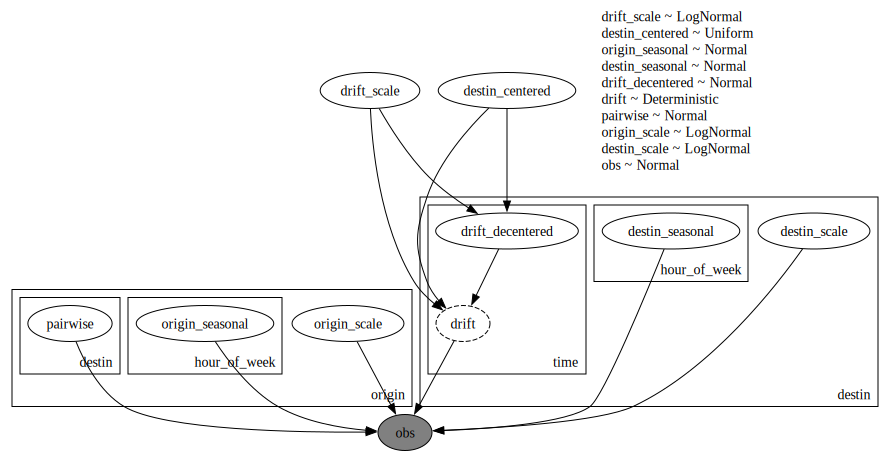

In [5]:
numpyro.render_model(
    HierarchicalForecaster(period=period),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

The full panel is large, so we draw predictive samples in memory-bounded batches and keep only what we plot (eight origins -> `ANTC`, last three training weeks).

prior band shape: (500, 8, 504)


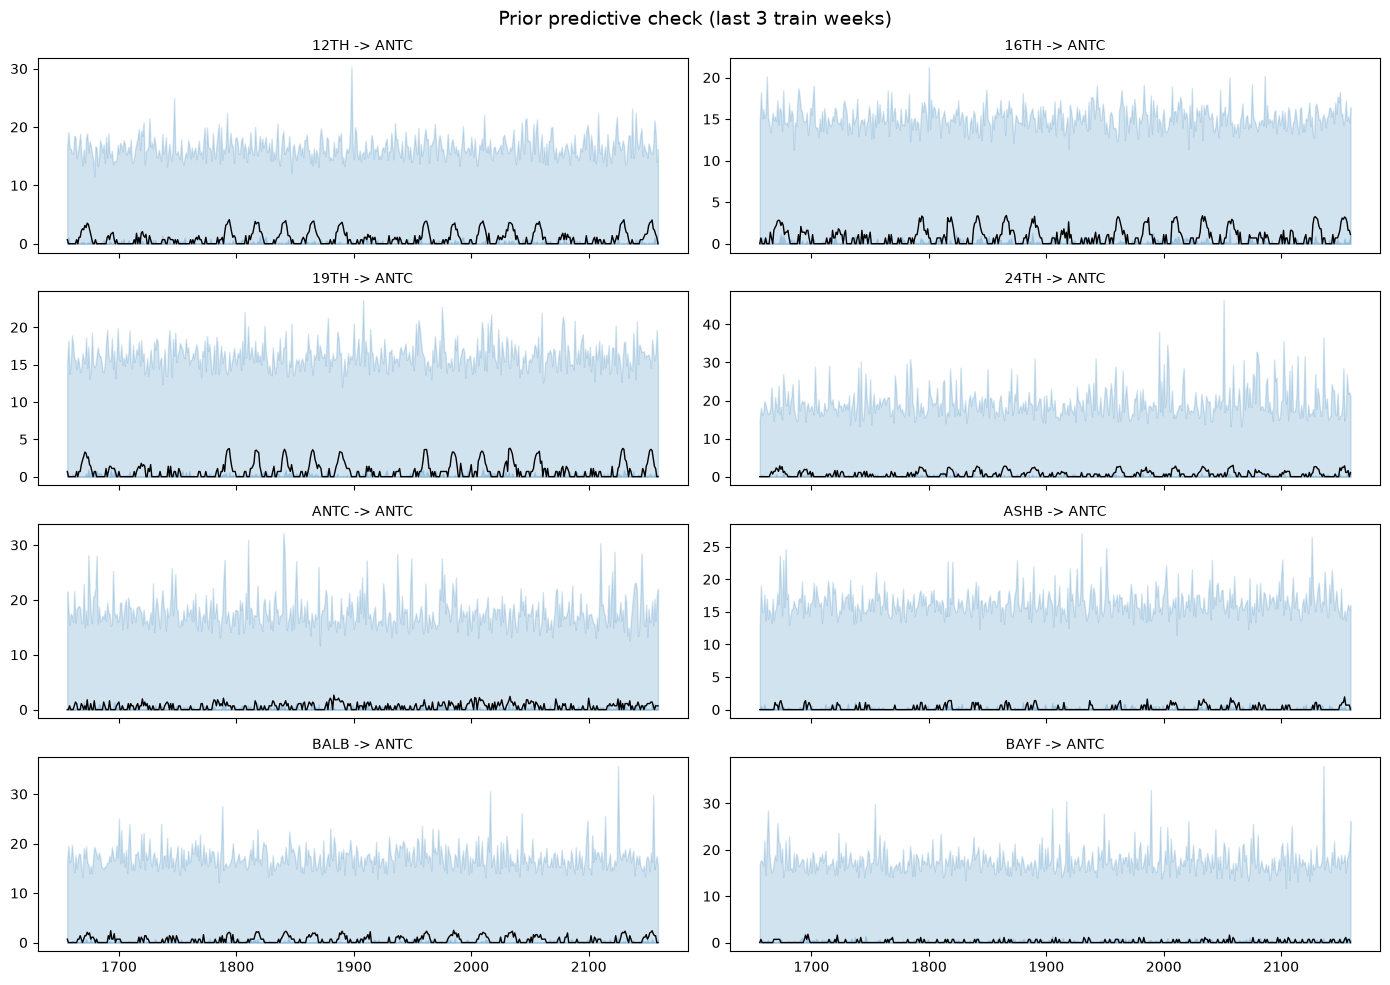

In [6]:
def hdi_bounds(samples: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(samples)
    da = xr.DataArray(arr[None], dims=["chain", "draw", "time"])
    band = az.hdi(da, prob=prob)
    return band.sel(ci_bound="lower").values, band.sel(ci_bound="upper").values


def batched_obs(make_pred, key, covariates, num_samples, batch_size, select=None):
    chunks = []
    for start in range(0, num_samples, batch_size):
        n = min(batch_size, num_samples - start)
        key, sub = random.split(key)
        obs = make_pred(start, n)(sub, covariates)["obs"]
        chunks.append(np.asarray(obs if select is None else select(obs)))
    return np.concatenate(chunks, axis=0)


model = HierarchicalForecaster(period=period)
n_plot = 8
lo = T1 - 3 * period  # last three train weeks

rng_key, rng_subkey = random.split(rng_key)
prior_band = batched_obs(
    lambda start, n: Predictive(model, num_samples=n, return_sites=["obs"]),
    rng_subkey,
    covariates_train,
    num_samples=500,
    batch_size=100,
    select=lambda o: o[:, :n_plot, lo:T1, antc],
)
print("prior band shape:", prior_band.shape)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes.ravel()):
    for prob in [0.94, 0.5]:
        lower, upper = hdi_bounds(prior_band[:, i, :].clip(min=0), prob)
        ax.fill_between(time_train[lo:T1], lower, upper, color="C0", alpha=0.2)
    ax.plot(time_train[lo:T1], np.asarray(y_train[i, lo:T1, antc]), color="black", lw=1)
    ax.set_title(f"{stations[i]} -> ANTC", fontsize=10)
fig.suptitle("Prior predictive check (last 3 train weeks)", fontsize=14)
fig.tight_layout();

## Inference with SVI

`Forecaster` fits the model with SVI (`AutoNormal` guide, `Adam`).

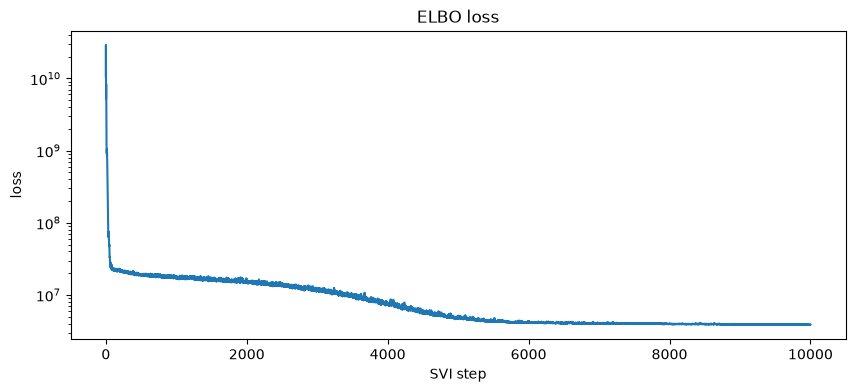

In [7]:
rng_key, rng_subkey = random.split(rng_key)
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.1),
    num_steps=10_000,
    rng_key=rng_subkey,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set_yscale("log")
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We draw the in-sample posterior predictive (batched to host memory for the full-panel train CRPS) and the forecast (batched via `Forecaster`'s `batch_size`). Predictions are clipped at zero before scoring with CRPS.

In [8]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)
num_post = 200

posterior_samples = forecaster.guide.sample_posterior(
    key_post, forecaster.params, sample_shape=(num_post,)
)
train_pp = batched_obs(
    lambda start, n: Predictive(
        model,
        posterior_samples=tree_map(lambda x: x[start : start + n], posterior_samples),
        return_sites=["obs"],
    ),
    key_pp,
    covariates_train,
    num_samples=num_post,
    batch_size=50,
)  # (num_post, origin, train, destin) on host

forecast = forecaster(y_train, covariates, num_samples=num_post, rng_key=key_fc, batch_size=50)
forecast = jnp.clip(forecast, min=0.0)

# Full-panel train CRPS, accumulated per origin to bound memory.
train_crps_per_origin = [
    eval_crps(jnp.clip(jnp.asarray(train_pp[:, i]), min=0.0), y_train[i]) for i in range(n_origin)
]
crps_train = float(np.mean(train_crps_per_origin))
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.2375
Test CRPS:  0.2786


## Forecast visualization

Eight origins -> `ANTC`: in-sample posterior predictive (blue, last 3 train weeks) and forecast (orange) with 50% / 94% HDI bands.

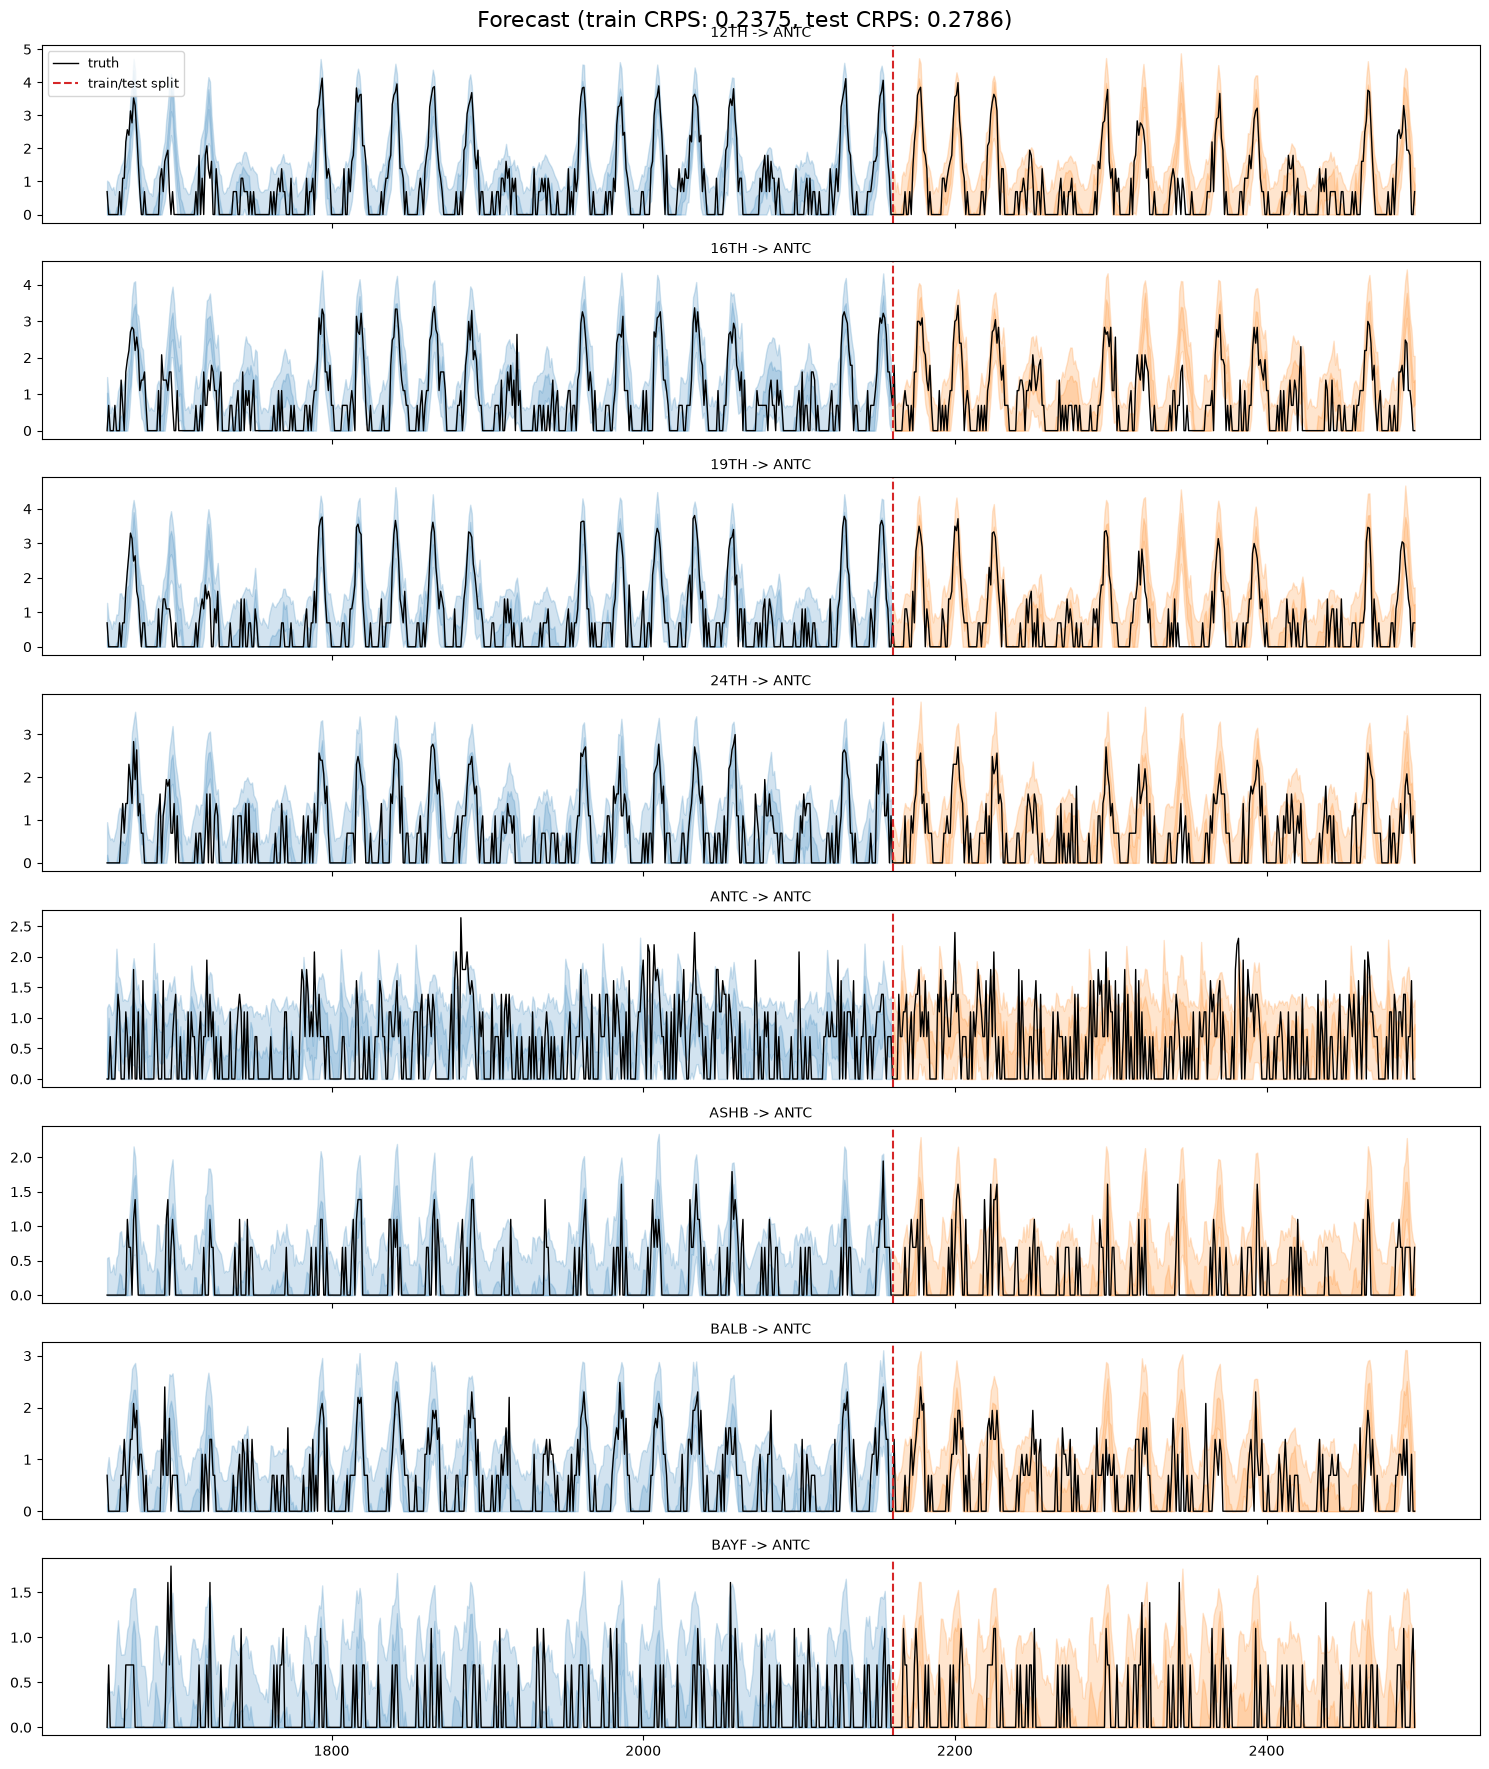

In [9]:
train_plot = np.clip(train_pp[:, :n_plot, lo:T1, antc], 0, None)
forecast_plot = np.asarray(forecast[:, :n_plot, :, antc])

fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(15, 18), sharex=True)
for i, ax in enumerate(axes):
    for prob in [0.94, 0.5]:
        lower, upper = hdi_bounds(train_plot[:, i], prob)
        ax.fill_between(time_train[lo:T1], lower, upper, color="C0", alpha=0.2)
        lower, upper = hdi_bounds(forecast_plot[:, i], prob)
        ax.fill_between(time_test, lower, upper, color="C1", alpha=0.2)
    ax.plot(time[lo:T2], np.asarray(y[i, lo:T2, antc]), color="black", lw=1, label="truth")
    ax.axvline(T1, color="C3", ls="--", label="train/test split")
    ax.set_title(f"{stations[i]} -> ANTC", fontsize=10)
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle(
    f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    fontsize=16,
)
fig.tight_layout();